# Diel Carbon Isotope Model for Shallow Lake Systems

## Coupled Python-PHREEQC Biogeochemical Model

This notebook simulates 24-hour (diel) variations in the carbon isotope composition of dissolved inorganic carbon (δ¹³C-DIC) in a shallow, unstratified lake system. The model mechanistically accounts for three primary carbon cycling processes:

1. **Atmospheric CO₂ exchange** – gas transfer across the air-water interface
2. **Gross Primary Productivity (GPP)** – photosynthetic CO₂/HCO₃⁻ uptake
3. **Ecosystem Respiration (ER)** – respiratory CO₂ production

### Key Features
- PHREEQC-based carbonate speciation at each time step
- Astronomically-computed sunrise/sunset for light-dependent GPP
- Mass-balance consistent isotope tracking
- Automated parameter calibration via multi-start optimization
- Publication-quality 8-panel diagnostic figures

### Requirements
```
numpy pandas matplotlib scipy phreeqpy astral
```


In [ ]:
# Install dependencies (uncomment if needed)
# !pip install numpy pandas matplotlib scipy phreeqpy astral

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from phreeqpy.iphreeqc.phreeqc_dll import IPhreeqc
from astral import LocationInfo
from astral.sun import sun
from scipy.optimize import minimize
from datetime import datetime, timezone, timedelta
import warnings, os
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

## Configuration

Set your site-specific parameters here. Modify `CSV_PATH` to point to your data file.

In [2]:
# ============================================================================
# USER CONFIGURATION - Modify these for your site
# ============================================================================
LATITUDE = 36.1627        # degrees N
LONGITUDE = -86.7816      # degrees W
TIMEZONE_OFFSET = -5      # UTC offset (e.g., -5 for CDT)
LAKE_DEPTH = 1.0          # meters (mean depth)
ATMOSPHERIC_d13C_CO2 = -8.5   # per mil VPDB
ORGANIC_MATTER_d13C = -28.0   # per mil VPDB (initial estimate)
ATMOSPHERIC_CO2_PPM = 425.0   # atmospheric CO2 concentration

# File paths
CSV_PATH = 'SL20241020.csv'  # Your input CSV file
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Inline PHREEQC Database

Minimal carbonate chemistry database for PHREEQC. Contains all species needed for CO₂-H₂O-CaCO₃ equilibrium calculations with temperature-dependent equilibrium constants (analytic expressions from Plummer & Busenberg, 1982).

In [3]:
PHREEQC_DATABASE = """
SOLUTION_MASTER_SPECIES
H        H+             -1.     H               1.008
H(0)     H2             0.0     H
H(1)     H+             -1.     0.0
E        e-             0.0     0.0             0.0
O        H2O            0.0     O               16.00
O(0)     O2             0.0     O
O(-2)    H2O            0.0     0.0
C        CO3-2          2.0     C               12.011
C(4)     CO3-2          2.0     CO3             12.011
Ca       Ca+2           0.0     Ca              40.08
Na       Na+            0.0     Na              22.99
Cl       Cl-            0.0     Cl              35.45
Alkalinity CO3-2        1.0     Ca              50.04
SOLUTION_SPECIES
H+ = H+
    log_k 0.0
e- = e-
    log_k 0.0
H2O = H2O
    log_k 0.0
CO3-2 = CO3-2
    log_k 0.0
Ca+2 = Ca+2
    log_k 0.0
Na+ = Na+
    log_k 0.0
Cl- = Cl-
    log_k 0.0
CO3-2 + H+ = HCO3-
    log_k 10.3288
    delta_h -3.561 kcal
    -analytic 107.8871 0.03252849 -5151.79 -38.92561 563713.9
CO3-2 + 2H+ = CO2 + H2O
    log_k 16.6809
    delta_h -5.738 kcal
    -analytic 464.1965 0.09344813 -26986.16 -165.75951 2248628.9
H2O = OH- + H+
    log_k -14.0
    delta_h 13.362 kcal
    -analytic -283.9710 -0.05069842 13323.0 102.24447 -1119669.0
2H2O = O2 + 4H+ + 4e-
    log_k -86.08
    delta_h 134.79 kcal
2H+ + 2e- = H2
    log_k -3.15
    delta_h -1.759 kcal
Ca+2 + CO3-2 = CaCO3
    log_k 3.224
    delta_h 3.545 kcal
Ca+2 + CO3-2 + H+ = CaHCO3+
    log_k 11.435
    delta_h -0.871 kcal
Ca+2 + H2O = CaOH+ + H+
    log_k -12.78
Na+ + CO3-2 = NaCO3-
    log_k 1.27
    delta_h 8.91 kcal
Na+ + CO3-2 + H+ = NaHCO3
    log_k 10.079
PHASES
CO2(g)
    CO2 = CO2 + H2O - H2O
    log_k -1.468
    delta_h -4.776 kcal
    -analytic 108.3865 0.01985076 -6919.53 -40.45154 669365.0
Calcite
    CaCO3 = CO3-2 + Ca+2
    log_k -8.48
    delta_h -2.297 kcal
    -analytic -171.9065 -0.077993 2839.319 71.595 0.0
END
"""

# Write database to temporary file for loading
db_path = os.path.join(OUTPUT_DIR, 'phreeqc_carb.dat')
with open(db_path, 'w') as f:
    f.write(PHREEQC_DATABASE)
print("PHREEQC database written to", db_path)

PHREEQC database written to output\phreeqc_carb.dat


## Helper Functions

Physical and geochemical utility functions:

- **`Sc_o2(T)`** / **`Sc_co2(T)`** — Schmidt numbers for O₂ and CO₂ in freshwater (Wanninkhof 2014)
- **`ko2_to_k600(ko2, T)`** / **`k600_to_kco2(k600, T)`** — Gas exchange coefficient conversions via Schmidt number ratios
- **`henry_co2(T)`** — Henry's law constant for CO₂ (Weiss 1974)
- **`create_phreeqc()`** — Initialize PHREEQC with inline carbonate database
- **`run_speciation(phreeqc, T, pH, DIC_mgC)`** — PHREEQC carbonate speciation

In [4]:
def Sc_o2(T):
    """Schmidt number for O2 in freshwater (Wanninkhof 2014).
    T in degrees Celsius. Valid 0-40 C."""
    return 1745.1 - 124.34*T + 4.8055*T**2 - 0.10115*T**3 + 0.00086842*T**4

def Sc_co2(T):
    """Schmidt number for CO2 in freshwater (Wanninkhof 2014).
    T in degrees Celsius. Valid 0-40 C."""
    return 1923.6 - 125.06*T + 4.3773*T**2 - 0.085681*T**3 + 0.00070284*T**4

def ko2_to_k600(ko2, T):
    """Convert KO2 (m d-1) to k600 (m d-1) via Schmidt number ratio."""
    return ko2 * (600.0 / Sc_o2(T))**(-0.5)

def k600_to_kco2(k600, T):
    """Convert k600 (m d-1) to kCO2 (m d-1) via Schmidt number ratio."""
    return k600 * (Sc_co2(T) / 600.0)**(-0.5)

def henry_co2(T):
    """Henry's law constant for CO2 in freshwater (mol kg-1 atm-1).
    Weiss (1974), Marine Chemistry 2:203-215."""
    TK = T + 273.15
    return np.exp(-58.0931 + 90.5069*(100.0/TK) + 22.294*np.log(TK/100.0))

def create_phreeqc():
    """Create and initialize a PHREEQC instance with the inline database."""
    db_path = os.path.join(OUTPUT_DIR, 'phreeqc_carb.dat')
    with open(db_path, 'w') as f:
        f.write(PHREEQC_DATABASE)
    p = IPhreeqc()
    p.load_database(db_path)
    if p.phc_database_error_count > 0:
        raise RuntimeError(f"PHREEQC DB error: {p.get_error_string()}")
    return p

def run_speciation(phreeqc, T, pH, DIC_mgC):
    """Run PHREEQC carbonate speciation.
    Returns: (pH, CO2_mol, HCO3_mol, CO3_mol, pCO2_uatm)
    where concentrations are in mol/kgw.
    """
    input_str = (
        f"SOLUTION 1\n"
        f"    temp {T}\n"
        f"    pH {pH}\n"
        f"    C(4) {DIC_mgC / 12.011}\n"
        f"    Na 10 charge\n"
        f"SELECTED_OUTPUT\n"
        f"    -reset false\n"
        f"    -pH\n"
        f"    -totals C(4)\n"
        f"    -molalities CO2 HCO3- CO3-2\n"
        f"    -si CO2(g)\n"
        f"END\n"
    )
    phreeqc.run_string(input_str)
    v = phreeqc.get_selected_output_array()[1]
    return v[0], v[2], v[3], v[4], 10**v[5] * 1e6

print("All helper functions defined:")
print("  Sc_o2, Sc_co2, ko2_to_k600, k600_to_kco2, henry_co2")
print("  create_phreeqc, run_speciation")

All helper functions defined:
  Sc_o2, Sc_co2, ko2_to_k600, k600_to_kco2, henry_co2
  create_phreeqc, run_speciation


## Data Loading and Validation

In [6]:
# Load CSV data
df_raw = pd.read_csv(CSV_PATH, encoding='utf-8-sig')
df_raw.columns = df_raw.columns.str.strip()
df_raw['DateTime'] = pd.to_datetime(df_raw['DateTime'], format='%m/%d/%y %H:%M')

# Rename columns
df_raw = df_raw.rename(columns={
    'DO (mg L-1)': 'DO', 'pH': 'pH_meas', 'Temperature (°C)': 'temp',
    'd13C-DIC (\u2030)': 'd13C_DIC', 'DIC  (mg L-1)': 'DIC_mgL',
    'GPP (mg O2 L-1 h-1)': 'GPP', 'R (mg O2 L-1 h-1)': 'ER',
    'KO2 (m d-1)': 'KO2',
}).rename(columns={'DateTime': 'datetime'})

# Store original observations
df_obs = df_raw.copy()
obs_times = df_obs['datetime'].values
obs_d13c = df_obs['d13C_DIC'].values

print(f"Data range: {df_raw['datetime'].min()} to {df_raw['datetime'].max()}")
print(f"N observations: {len(df_raw)}")
print(f"\u03b4\u00b9\u00b3C-DIC: {df_raw['d13C_DIC'].min():.2f} to {df_raw['d13C_DIC'].max():.2f} \u2030")
print(f"DIC: {df_raw['DIC_mgL'].min():.2f} to {df_raw['DIC_mgL'].max():.2f} mg/L")
print(f"Temperature: {df_raw['temp'].min():.1f} to {df_raw['temp'].max():.1f} °C")
print(f"pH: {df_raw['pH_meas'].min():.2f} to {df_raw['pH_meas'].max():.2f}")
df_raw.head()

Data range: 2024-10-18 18:00:00 to 2024-10-20 18:00:00
N observations: 13
δ¹³C-DIC: -7.69 to -7.03 ‰
DIC: 16.29 to 17.04 mg/L
Temperature: 14.6 to 18.0 °C
pH: 7.51 to 7.85


,datetime,DO,pH_meas,temp,d13C_DIC,DIC_mgL,GPP,ER,KO2
0,2024-10-18 18:00:00,8.92,7.72,16.841,-7.17,16.38,0.534519,-6.118821,0.700
1,2024-10-18 22:00:00,8.27,7.60,15.806,-7.24,16.29,0.000000,-5.475336,0.625
2,2024-10-19 02:00:00,8.16,7.51,15.115,-7.40,16.44,0.000000,-5.023120,0.554
3,2024-10-19 06:00:00,8.23,7.55,14.629,-7.57,16.76,0.000000,-4.407511,0.503
4,2024-10-19 10:00:00,8.58,7.57,15.285,-7.39,16.57,5.442637,-5.113840,0.425


In [7]:
# Interpolate to hourly resolution
df = df_raw.set_index('datetime').resample('1h').interpolate(method='linear').reset_index()
n = len(df)
print(f"Interpolated to {n} hourly time steps")

Interpolated to 49 hourly time steps


## Solar Geometry and Photoperiod

In [8]:
# Calculate sunrise/sunset for each date
tz = timezone(timedelta(hours=TIMEZONE_OFFSET))
sun_info = {}
for d in df['datetime'].dt.date.unique():
    loc = LocationInfo("Lake", "Region", "UTC", LATITUDE, LONGITUDE)
    s = sun(loc.observer, date=d, tzinfo=tz)
    sun_info[d] = (s['sunrise'], s['sunset'])
    print(f"  {d}: Sunrise {s['sunrise'].strftime('%H:%M')}, Sunset {s['sunset'].strftime('%H:%M')}")

# Build daylight flag array
day_flag = np.zeros(n, dtype=bool)
for i in range(n):
    dt = df['datetime'].iloc[i]
    sr, ss = sun_info[dt.date()]
    day_flag[i] = sr <= dt.replace(tzinfo=tz) <= ss

print(f"\nDaylight hours: {day_flag.sum()}/{n} time steps")

  2024-10-18: Sunrise 06:57, Sunset 18:06
  2024-10-19: Sunrise 06:58, Sunset 18:04
  2024-10-20: Sunrise 06:59, Sunset 18:03

Daylight hours: 25/49 time steps


## PHREEQC Carbonate Speciation

Pre-compute speciation for all time steps using measured pH, temperature, and DIC. This avoids repeated PHREEQC calls during optimization.

In [9]:
# Initialize PHREEQC and pre-compute speciation
phreeqc = create_phreeqc()

pH_mod = np.zeros(n); CO2_mol = np.zeros(n); HCO3_mol = np.zeros(n)
CO3_mol = np.zeros(n); DIC_mol = np.zeros(n); pCO2_arr = np.zeros(n)
fCO2 = np.zeros(n); fHCO3 = np.zeros(n); fCO3 = np.zeros(n)

for i in range(n):
    pH_mod[i], CO2_mol[i], HCO3_mol[i], CO3_mol[i], pCO2_arr[i] = \
        run_speciation(phreeqc, df['temp'].iloc[i], df['pH_meas'].iloc[i], df['DIC_mgL'].iloc[i])
    DIC_mol[i] = CO2_mol[i] + HCO3_mol[i] + CO3_mol[i]
    if DIC_mol[i] > 0:
        fCO2[i] = CO2_mol[i] / DIC_mol[i]
        fHCO3[i] = HCO3_mol[i] / DIC_mol[i]
        fCO3[i] = CO3_mol[i] / DIC_mol[i]

# Pre-compute derived arrays
temp = df['temp'].values; TK = temp + 273.15
DIC_mgL = df['DIC_mgL'].values; GPP_raw = df['GPP'].values; ER_raw = df['ER'].values
KO2_raw = df['KO2'].values; RQ = 12.011 / 32.0

# Equilibrium fractionation factors (Mook et al. 1974)
eps_hco3 = 9866.0 / TK - 24.12  # HCO3 enriched vs CO2(aq)
eps_co3 = eps_hco3 + 0.6
weighted_eps = fHCO3 * eps_hco3 + fCO3 * eps_co3

# Measured DIC change per hour
dDIC_dt = np.diff(DIC_mgL, prepend=DIC_mgL[0])

# Gas exchange from pCO2 (for reporting)
k600_base = np.array([KO2_raw[i] * (600 / Sc_o2(temp[i]))**(-0.5) for i in range(n)])
kco2_base = np.array([k600_base[i] * (Sc_co2(temp[i]) / 600)**(-0.5) for i in range(n)])
CO2_eq = np.array([henry_co2(temp[i]) * ATMOSPHERIC_CO2_PPM * 1e-6 for i in range(n)])
flux_mmol = kco2_base * (CO2_mol - CO2_eq) * 1e6  # mmol/m2/d

print(f"Initial speciation: CO2={CO2_mol[0]*44010:.1f}, HCO3={HCO3_mol[0]*61017:.1f}, "
      f"CO3={CO3_mol[0]*60009:.1f} mg/L")
print(f"Initial pCO2: {pCO2_arr[0]:.0f} µatm")

Initial speciation: CO2=2.7, HCO3=79.3, CO3=0.2 mg/L
Initial pCO2: 1401 µatm


## Isotope Mass Balance Model

The model tracks δ¹³C-DIC evolution using:
- **Measured DIC** as constraint (avoids mass balance drift)
- **Mass-balance closure** for gas exchange: gas\_C = ER\_C - GPP\_C - dDIC/dt
- **Equilibrium fractionation** between CO₂(aq), HCO₃⁻, and CO₃²⁻ (Mook et al., 1974)
- **Photosynthetic fractionation** during mixed CO₂/HCO₃⁻ uptake
- **Kinetic fractionation** during gas exchange (-0.8‰)

### Calibration Parameters
1. `er_scale` — ER rate scaling factor
2. `pf` — Photosynthetic fractionation factor (‰)
3. `gpp_scale` — GPP rate scaling factor
4. `d13c_org` — δ¹³C of respired organic matter (‰)
5. `k_gas_iso` — Gas exchange isotope effect scaling

In [10]:
def run_isotope_model(pvec):
    """
    Fast isotope evolution model using pre-computed PHREEQC speciation.
    
    Parameters:
        pvec[0]: er_scale - ER scaling factor
        pvec[1]: pf - photosynthetic fractionation (per mil)
        pvec[2]: gpp_scale - GPP scaling factor
        pvec[3]: d13c_org - d13C of respired organic matter
        pvec[4]: k_gas_iso - gas exchange isotope scaling
    
    Returns: d13C-DIC time series (array)
    """
    er_sc, pf, gpp_sc, d13c_org, k_iso = pvec
    
    d13C = np.zeros(n)
    d13C[0] = df['d13C_DIC'].iloc[0]
    
    for i in range(1, n):
        # Carbon fluxes (mg C / L / h)
        gpp_eff = GPP_raw[i] * gpp_sc if day_flag[i] else 0.0
        er_eff = ER_raw[i] * er_sc  # negative value
        
        gpp_C = gpp_eff * RQ   # C removed by GPP
        er_C = -er_eff * RQ    # C added by ER (positive)
        
        # Gas exchange from mass balance closure
        gas_C = er_C - gpp_C - dDIC_dt[i]  # positive = outgassing
        
        # d13C of CO2(aq) from equilibrium with DIC
        d13C_CO2 = d13C[i-1] - weighted_eps[i-1]
        d13C_HCO3 = d13C_CO2 + eps_hco3[i-1]
        
        # ER: adds carbon with organic matter d13C
        iso_er = er_C * d13c_org
        
        # GPP: removes carbon with photosynthetic fractionation
        # Mixed CO2/HCO3- uptake weighted by speciation
        d13C_gpp = fCO2[i-1] * (d13C_CO2 + pf) + fHCO3[i-1] * (d13C_HCO3 + pf)
        iso_gpp = gpp_C * d13C_gpp
        
        # Gas exchange isotope effect
        if gas_C > 0:  # net outgassing
            iso_gas = gas_C * (d13C_CO2 + (-0.8)) * k_iso  # kinetic fractionation
        else:  # net ingassing
            eps_eq = -0.373 * 1000 / TK[i-1] + 0.19
            iso_gas = gas_C * (ATMOSPHERIC_d13C_CO2 - eps_eq) * k_iso
        
        # Isotope mass balance
        numerator = DIC_mgL[i-1] * d13C[i-1] + iso_er - iso_gpp - iso_gas
        d13C[i] = numerator / DIC_mgL[i] if DIC_mgL[i] > 0.5 else d13C[i-1]
    
    return d13C

def objective_function(pvec):
    """RMSE objective for optimization."""
    d13C = run_isotope_model(pvec)
    mod = np.interp(obs_times.astype(np.float64),
                    df['datetime'].values.astype(np.float64), d13C)
    if not np.all(np.isfinite(mod)):
        return 100.0
    return np.sqrt(np.mean((obs_d13c - mod)**2))

print("Model functions defined.")

Model functions defined.


## Parameter Calibration

Multi-start Nelder-Mead optimization to find parameters that minimize RMSE between modeled and observed δ¹³C-DIC.

In [11]:
# Multi-start optimization
print("Running multi-start optimization...")
best_rmse = 999
best_x = None

starting_points = [
    [1.0, -20, 1.0, -28, 1.0],
    [1.0, -15, 1.0, -28, 1.0],
    [1.0, -25, 1.0, -28, 1.0],
    [0.8, -20, 1.0, -26, 1.0],
    [1.2, -20, 1.0, -30, 1.5],
    [1.0, -18, 0.9, -27, 0.7],
    [0.9, -22, 1.1, -29, 1.2],
    [1.1, -16, 0.95, -25, 0.8],
]

for j, x0 in enumerate(starting_points):
    res = minimize(objective_function, x0, method='Nelder-Mead',
                   options={'maxiter': 2000, 'xatol': 1e-4, 'fatol': 1e-5})
    if res.fun < best_rmse:
        best_rmse = res.fun
        best_x = res.x.copy()
    print(f"  Start {j+1}/8: RMSE = {res.fun:.4f}")

# Polish
res_final = minimize(objective_function, best_x, method='Nelder-Mead',
                     options={'maxiter': 5000, 'xatol': 1e-6, 'fatol': 1e-7})
best_x = res_final.x
best_rmse = res_final.fun

param_names = ['ER scale', 'PF (‰)', 'GPP scale', 'δ¹³C-org (‰)', 'k_gas_iso']
print(f"\nOptimized Parameters (RMSE = {best_rmse:.4f} ‰):")
for name, val in zip(param_names, best_x):
    print(f"  {name:>15s}: {val:.4f}")

Running multi-start optimization...
  Start 1/8: RMSE = 0.0692
  Start 2/8: RMSE = 0.0692
  Start 3/8: RMSE = 0.0830
  Start 4/8: RMSE = 0.0692
  Start 5/8: RMSE = 0.0692
  Start 6/8: RMSE = 0.0727
  Start 7/8: RMSE = 0.0692
  Start 8/8: RMSE = 0.0692

Optimized Parameters (RMSE = 0.0692 ‰):
         ER scale: 0.5242
           PF (‰): -6.9987
        GPP scale: 0.4150
     δ¹³C-org (‰): -14.0722
        k_gas_iso: 0.7769


## Final Model Run and Statistics

In [12]:
# Run final model
d13C_final = run_isotope_model(best_x)

# Fit statistics at observation points
mod_at_obs = np.interp(obs_times.astype(np.float64),
                       df['datetime'].values.astype(np.float64), d13C_final)
rmse = np.sqrt(np.mean((obs_d13c - mod_at_obs)**2))
ss_res = np.sum((obs_d13c - mod_at_obs)**2)
ss_tot = np.sum((obs_d13c - np.mean(obs_d13c))**2)
r2 = 1 - ss_res / ss_tot

print(f"FIT STATISTICS (δ¹³C-DIC)")
print(f"  RMSE:  {rmse:.4f} ‰")
print(f"  R²:    {r2:.4f}")
print(f"  N obs: {len(obs_d13c)}")
print(f"\nPoint-by-point comparison:")
print(f"  {'DateTime':>16s}  {'Observed':>8s}  {'Modeled':>8s}  {'Residual':>8s}")
for i in range(len(obs_d13c)):
    t_str = pd.Timestamp(obs_times[i]).strftime('%m/%d %H:%M')
    print(f"  {t_str:>16s}  {obs_d13c[i]:8.2f}  {mod_at_obs[i]:8.2f}  {obs_d13c[i]-mod_at_obs[i]:+8.3f}")

FIT STATISTICS (δ¹³C-DIC)
  RMSE:  0.0692 ‰
  R²:    0.8681
  N obs: 13

Point-by-point comparison:
          DateTime  Observed   Modeled  Residual
       10/18 18:00     -7.17     -7.17    +0.000
       10/18 22:00     -7.24     -7.27    +0.033
       10/19 02:00     -7.40     -7.44    +0.039
       10/19 06:00     -7.57     -7.62    +0.055
       10/19 10:00     -7.39     -7.51    +0.119
       10/19 14:00     -7.14     -7.15    +0.007
       10/19 18:00     -7.03     -7.19    +0.159
       10/19 22:00     -7.37     -7.32    -0.052
       10/20 02:00     -7.53     -7.46    -0.066
       10/20 06:00     -7.69     -7.61    -0.076
       10/20 10:00     -7.57     -7.52    -0.053
       10/20 14:00     -7.19     -7.20    +0.011
       10/20 18:00     -7.27     -7.23    -0.038


In [13]:
# Build comprehensive results DataFrame
gpp_opt = np.where(day_flag, GPP_raw * best_x[2], 0.0)
er_opt = ER_raw * best_x[0]

results = pd.DataFrame({
    'DateTime': df['datetime'],
    'Temperature_C': temp,
    'pH_measured': df['pH_meas'].values,
    'pH_modeled': pH_mod,
    'pCO2_uatm': pCO2_arr,
    'GPP_input_mgO2Lh': GPP_raw,
    'GPP_optimized_mgO2Lh': gpp_opt,
    'ER_input_mgO2Lh': ER_raw,
    'ER_optimized_mgO2Lh': er_opt,
    'NEP_mgO2Lh': gpp_opt + er_opt,
    'KO2_m_d': KO2_raw,
    'k600_m_d': k600_base,
    'CO2flux_mmol_m2_d': flux_mmol,
    'CO2aq_mgL': CO2_mol * 44010,
    'HCO3_mgL': HCO3_mol * 61017,
    'CO3_mgL': CO3_mol * 60009,
    'DIC_mgL': DIC_mgL,
    'd13C_DIC_measured_permil': df['d13C_DIC'].values,
    'd13C_DIC_modeled_permil': d13C_final,
    'd13C_residual_permil': df['d13C_DIC'].values - d13C_final,
    'Daylight_flag': day_flag.astype(int),
})

# Export CSV
csv_path = os.path.join(OUTPUT_DIR, 'diel_model_results.csv')
results.to_csv(csv_path, index=False, float_format='%.6f')
print(f"Results exported to {csv_path}")
results.head()

Results exported to output\diel_model_results.csv


,DateTime,Temperature_C,pH_measured,pH_modeled,pCO2_uatm,GPP_input_mgO2Lh,GPP_optimized_mgO2Lh,ER_input_mgO2Lh,ER_optimized_mgO2Lh,NEP_mgO2Lh,...,k600_m_d,CO2flux_mmol_m2_d,CO2aq_mgL,HCO3_mgL,CO3_mgL,DIC_mgL,d13C_DIC_measured_permil,d13C_DIC_modeled_permil,d13C_residual_permil,Daylight_flag
0,2024-10-18 18:00:00,16.84100,7.72,7.72,1401.394313,0.534519,0.221819,-6.118821,-3.207380,-2.985562,...,0.700433,27.168522,2.656059,79.298907,0.180271,16.3800,-7.1700,-7.170000,0.000000,1
1,2024-10-18 19:00:00,16.58225,7.69,7.69,1489.798260,0.400890,0.000000,-5.957950,-3.123054,-3.123054,...,0.686391,29.066094,2.846198,78.936086,0.166341,16.3575,-7.1875,-7.198964,0.011464,0
2,2024-10-18 20:00:00,16.32350,7.66,7.66,1583.389094,0.267260,0.000000,-5.797079,-3.038728,-3.038728,...,0.672145,30.998833,3.049296,78.554243,0.153439,16.3350,-7.2050,-7.225562,0.020562,0
3,2024-10-18 21:00:00,16.06475,7.63,7.63,1682.417877,0.133630,0.000000,-5.636207,-2.954402,-2.954402,...,0.657693,32.962176,3.266137,78.152372,0.141491,16.3125,-7.2225,-7.250118,0.027618,0
4,2024-10-18 22:00:00,15.80600,7.60,7.60,1787.140113,0.000000,0.000000,-5.475336,-2.870076,-2.870076,...,0.643031,34.950747,3.497534,77.729416,0.130427,16.2900,-7.2400,-7.272926,0.032926,0


## Publication-Quality Visualization

Eight-panel figure showing all model outputs with nighttime shading and observed vs. modeled comparisons.

Figure saved: output\diel_model_results.svg
Figure saved: output\diel_model_results.png


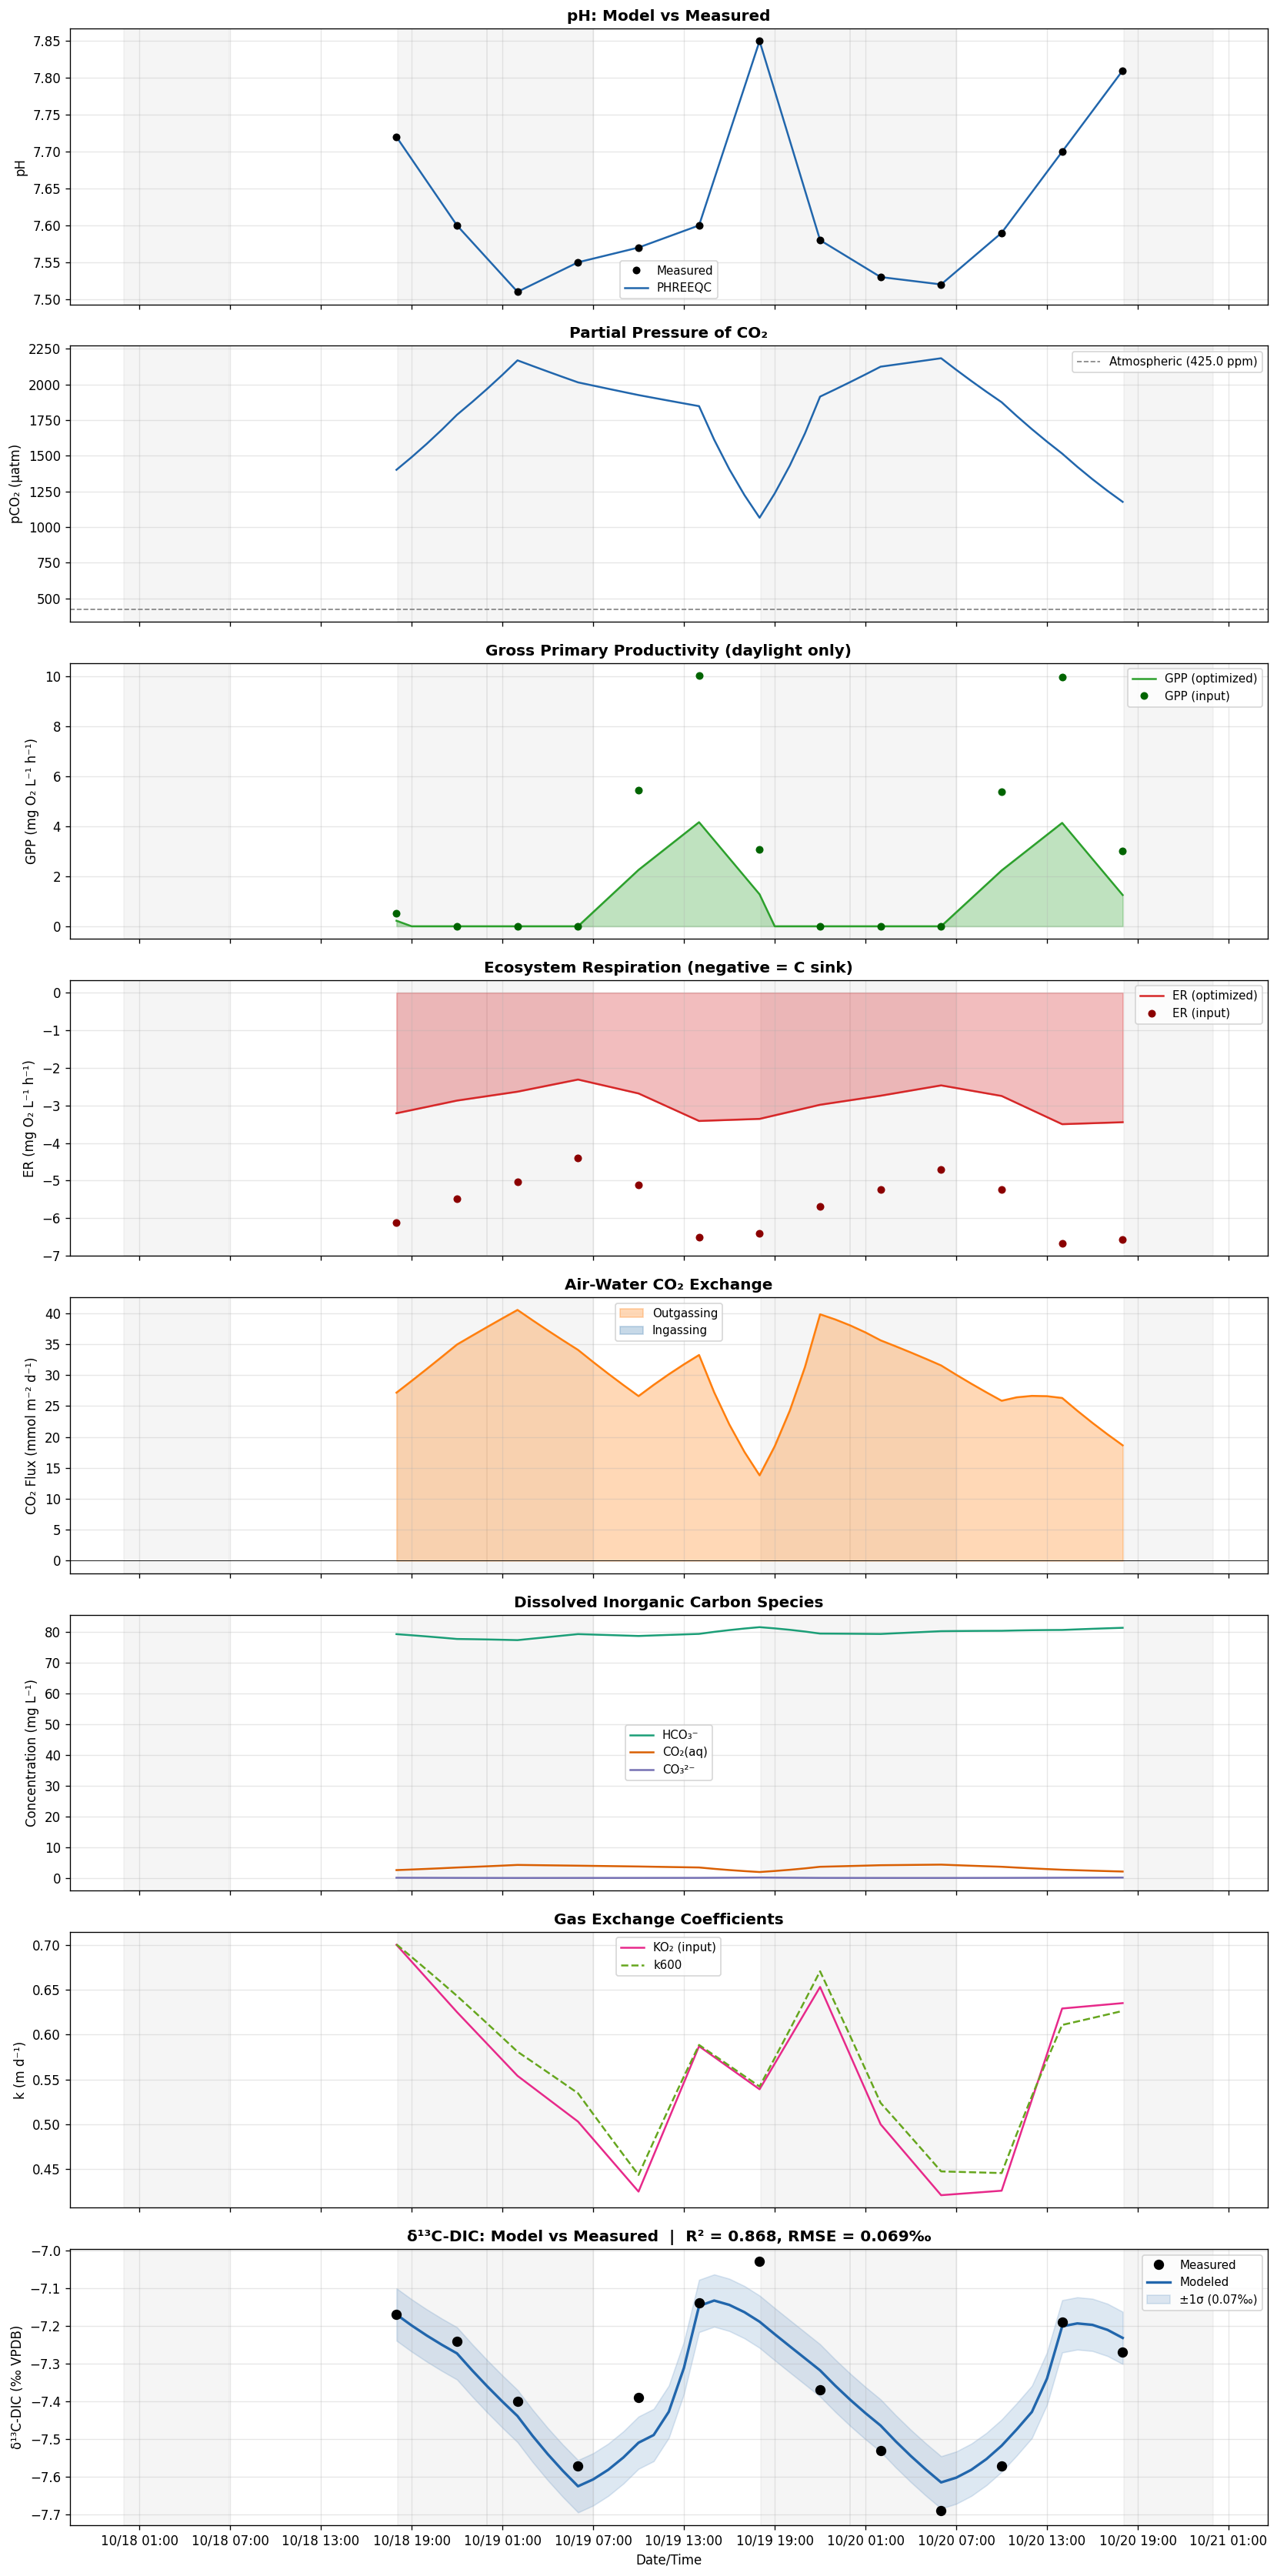

In [14]:
# Color scheme
c_obs, c_mod = '#1a1a1a', '#2166ac'
c_gpp, c_er, c_flux = '#2ca02c', '#d62728', '#ff7f0e'

# Night shading spans
night_spans = []
for d in df['datetime'].dt.date.unique():
    sr, ss = sun_info[d]
    t0 = pd.Timestamp(datetime.combine(d, datetime.min.time()))
    night_spans.append((t0, pd.Timestamp(sr.replace(tzinfo=None))))
    night_spans.append((pd.Timestamp(ss.replace(tzinfo=None)), t0 + pd.Timedelta(days=1)))

def add_night_shading(ax):
    for s, e in night_spans:
        ax.axvspan(s, e, alpha=0.08, color='gray', zorder=0)

tt = results['DateTime']
odt = df_obs['datetime']

fig, axes = plt.subplots(8, 1, figsize=(14, 28), sharex=True)

# 1 - pH
ax = axes[0]
ax.plot(odt, df_obs['pH_meas'], 'ko', ms=5, label='Measured', zorder=3)
ax.plot(tt, results['pH_modeled'], '-', color=c_mod, lw=1.5, label='PHREEQC')
add_night_shading(ax); ax.set_ylabel('pH'); ax.legend(fontsize=9)
ax.set_title('pH: Model vs Measured', fontweight='bold'); ax.grid(alpha=0.3)

# 2 - pCO2
ax = axes[1]
ax.plot(tt, results['pCO2_uatm'], '-', color=c_mod, lw=1.5)
ax.axhline(ATMOSPHERIC_CO2_PPM, color='gray', ls='--', lw=1, label=f'Atmospheric ({ATMOSPHERIC_CO2_PPM} ppm)')
add_night_shading(ax); ax.set_ylabel('pCO₂ (µatm)'); ax.legend(fontsize=9)
ax.set_title('Partial Pressure of CO₂', fontweight='bold'); ax.grid(alpha=0.3)

# 3 - GPP
ax = axes[2]
ax.fill_between(tt, 0, results['GPP_optimized_mgO2Lh'], color=c_gpp, alpha=0.3)
ax.plot(tt, results['GPP_optimized_mgO2Lh'], '-', color=c_gpp, lw=1.5, label='GPP (optimized)')
ax.plot(odt, df_obs['GPP'], 'o', color='darkgreen', ms=5, label='GPP (input)')
add_night_shading(ax); ax.set_ylabel('GPP (mg O₂ L⁻¹ h⁻¹)'); ax.legend(fontsize=9)
ax.set_title('Gross Primary Productivity (daylight only)', fontweight='bold'); ax.grid(alpha=0.3)

# 4 - ER (negative values)
ax = axes[3]
ax.fill_between(tt, 0, results['ER_optimized_mgO2Lh'], color=c_er, alpha=0.3)
ax.plot(tt, results['ER_optimized_mgO2Lh'], '-', color=c_er, lw=1.5, label='ER (optimized)')
ax.plot(odt, df_obs['ER'], 'o', color='darkred', ms=5, label='ER (input)')
add_night_shading(ax); ax.set_ylabel('ER (mg O₂ L⁻¹ h⁻¹)'); ax.legend(fontsize=9)
ax.set_title('Ecosystem Respiration (negative = C sink)', fontweight='bold'); ax.grid(alpha=0.3)

# 5 - CO2 Flux
ax = axes[4]
ax.fill_between(tt, 0, results['CO2flux_mmol_m2_d'],
                where=results['CO2flux_mmol_m2_d'] >= 0, color=c_flux, alpha=0.3, label='Outgassing')
ax.fill_between(tt, 0, results['CO2flux_mmol_m2_d'],
                where=results['CO2flux_mmol_m2_d'] < 0, color='steelblue', alpha=0.3, label='Ingassing')
ax.plot(tt, results['CO2flux_mmol_m2_d'], '-', color=c_flux, lw=1.5)
ax.axhline(0, color='k', lw=0.5)
add_night_shading(ax); ax.set_ylabel('CO₂ Flux (mmol m⁻² d⁻¹)'); ax.legend(fontsize=9)
ax.set_title('Air-Water CO₂ Exchange', fontweight='bold'); ax.grid(alpha=0.3)

# 6 - Carbon species
ax = axes[5]
ax.plot(tt, results['HCO3_mgL'], '-', color='#1b9e77', lw=1.5, label='HCO₃⁻')
ax.plot(tt, results['CO2aq_mgL'], '-', color='#d95f02', lw=1.5, label='CO₂(aq)')
ax.plot(tt, results['CO3_mgL'], '-', color='#7570b3', lw=1.5, label='CO₃²⁻')
add_night_shading(ax); ax.set_ylabel('Concentration (mg L⁻¹)'); ax.legend(fontsize=9)
ax.set_title('Dissolved Inorganic Carbon Species', fontweight='bold'); ax.grid(alpha=0.3)

# 7 - Gas exchange coefficients
ax = axes[6]
ax.plot(tt, results['KO2_m_d'], '-', color='#e7298a', lw=1.5, label='KO₂ (input)')
ax.plot(tt, results['k600_m_d'], '--', color='#66a61e', lw=1.5, label='k600')
add_night_shading(ax); ax.set_ylabel('k (m d⁻¹)'); ax.legend(fontsize=9)
ax.set_title('Gas Exchange Coefficients', fontweight='bold'); ax.grid(alpha=0.3)

# 8 - δ¹³C-DIC (PRIMARY TARGET)
ax = axes[7]
ax.plot(odt, obs_d13c, 'ko', ms=7, zorder=3, label='Measured')
ax.plot(tt, d13C_final, '-', color=c_mod, lw=2, zorder=2, label='Modeled')
ax.fill_between(tt, d13C_final - rmse, d13C_final + rmse,
                color=c_mod, alpha=0.15, label=f'±1σ ({rmse:.2f}‰)')
add_night_shading(ax)
ax.set_ylabel('δ¹³C-DIC (‰ VPDB)'); ax.set_xlabel('Date/Time')
ax.legend(fontsize=9)
ax.set_title(f'δ¹³C-DIC: Model vs Measured  |  R² = {r2:.3f}, RMSE = {rmse:.3f}‰',
             fontweight='bold')
ax.grid(alpha=0.3)

# Format x-axis
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))

plt.tight_layout()

# Save figures
for fmt in ['svg', 'png']:
    fig_path = os.path.join(OUTPUT_DIR, f'diel_model_results.{fmt}')
    fig.savefig(fig_path, format=fmt, dpi=150, bbox_inches='tight')
    print(f"Figure saved: {fig_path}")

plt.show()

## Summary

This model demonstrates the coupled Python-PHREEQC approach to simulating diel δ¹³C-DIC dynamics. Key outputs:

- **CSV file** with all time series data at hourly resolution
- **SVG/PNG figures** with 8-panel diagnostic plots
- **Optimized parameters** for the isotope mass balance

### Notes on Parameter Interpretation
- The optimization finds the best mathematical fit; some parameters may trade off against each other (equifinality)
- The mass-balance closure approach for gas exchange ensures carbon conservation
- PHREEQC provides thermodynamically consistent carbonate speciation at each time step
- Fractionation factors follow Mook et al. (1974) for equilibrium and literature values for kinetic effects

### Potential Improvements
- Add sub-hourly time stepping for better temporal resolution
- Include isotope-enabled PHREEQC (13C as separate master species)
- Implement Bayesian parameter estimation for uncertainty quantification
- Account for groundwater DIC inputs if significant
